In [42]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
# TASK 3.1: ONE-PIXEL ATTACK IMPLEMENTATION

## Part A: Load CIFAR-10 Sample and Target Model
#This section loads a CIFAR-10 image and a pretrained ResNet-18 model to establish baseline performance before attacking.


In [43]:
#  ====
# STEP 1: LOAD AND PREPROCESS CIFAR-10 DATASET

# ResNet-18 was pretrained on ImageNet, so we use ImageNet preprocessing:
# - Resize to 224x224 (ResNet input size)
# - Normalize with ImageNet mean and std
# Documentation found: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html
transform = transforms.Compose([
    transforms.Resize((224, 224)),         # Resize to ResNet-18 input size
    transforms.ToTensor(),                 # Convert to [0,1] tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        # ImageNet normalization mean
        std=[0.229, 0.224, 0.225]          # ImageNet normalization std 
    ),
])

# Load CIFAR-10 test set (we don't train, just attack)
test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
loader = DataLoader(test_set, batch_size=1, shuffle=True)

# Get one sample image and its label
img, cifar_label = next(iter(loader))
img = img.to(device)
cifar_label = int(cifar_label.item())


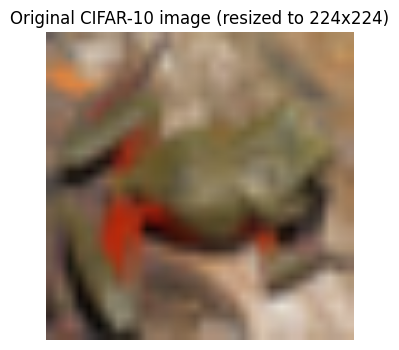

In [44]:

# VISUALIZATION UTILITIES

# Define ImageNet normalization constants for denormalization during visualization

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

def denorm_imagenet(x):
    """
    Convert ImageNet-normalized tensor back to [0,1] range for visualization.
    Formula: original = (normalized * std) + mean
    """
    x = x * IMAGENET_STD + IMAGENET_MEAN
    return torch.clamp(x, 0, 1)

def show_tensor_image(x, title=""):
    """Display a single normalized image tensor."""
    x = denorm_imagenet(x).detach().cpu()[0]  # Denormalize and move to CPU
    x = x.permute(1,2,0).numpy()              # Convert (3,H,W) -> (H,W,3)
    plt.imshow(x)
    plt.title(title)
    plt.axis('off')

# Display the original clean image
plt.figure(figsize=(4,4))
show_tensor_image(img, "Original CIFAR-10 image (resized to 224x224)")
plt.show()


In [ ]:

# STEP 2: LOAD PRETRAINED RESNET-18

# Load ResNet-18 pretrained on ImageNet and move to device
model = models.resnet18(weights='IMAGENET1K_V1').to(device)
model.eval()

# Evaluate baseline prediction on the sample image
with torch.no_grad():
    logits = model(img)
    probs = F.softmax(logits, dim=1)[0]
    clean_pred = int(torch.argmax(probs).item()) # clean is the standard name for the baseline image that has not permuted
    clean_conf = float(torch.max(probs).item())

print(f"Baseline - pred: {clean_pred}, conf: {clean_conf:.4f}")


Baseline - pred: 98, conf: 0.2915


In [ ]:
# ONE-PIXEL ATTACK IMPLEMENTATION (TASK 3.1)
# USING  POPULATION-BASED DIFFERENTIAL EVOLUTION 


def one_pixel_attack(model, img, label, iters=3000, step_xy=12, step_rgb=0.6, verbose=True, pop_size=400, F_de=0.8, CR_de=0.7):
    """
    One-Pixel Attack using Population-Based Differential Evolution.
    
    MUTATION STRATEGY: DE/best/1 
    FITNESS FUNCTION: (1 - P(original_class)) - maximize to reduce confidence
    CONSTRAINT HANDLING: Clip coordinates and RGB values to valid ranges
    
    Args:
        model: PyTorch model in eval mode
        img: Input image tensor (1, 3, H, W) on device
        label: Target label (original prediction to fool)
        iters: Number of generations (3000 default)
        step_xy: Max pixel coordinate range (12 default)
        step_rgb: Max RGB value range (0.6 default)
        verbose: Print progress information (default: False)
        pop_size: Population size (default: 400), which correspons to the paper
        F_de: F_de is the scale parameter (default: 0.5), which corresponds to the paper
        
    Returns:
        best: Best candidate found [x, y, r, g, b]
        iterations_used: Number of iterations before success (or max if no success)
        success: Boolean indicating if attack succeeded
    """
    model.eval()
    device = img.device
    _, _, H, W = img.shape # Getting the images' hight and width
    
    # 
    # HELPER FUNCTION 1: Apply a candidate to the image
    # 
    def apply_pixel(candidate):
        """Modify exactly one pixel in the image according to candidate [x,y,r,g,b]."""
        x, y, r, g, b = candidate
        x = int(np.clip(round(x), 0, W - 1)) # Ensures x values is between 0 and the width of image
        y = int(np.clip(round(y), 0, H - 1)) # Ensures y value is between 0 and height of image
        tmp = img.clone()   # clone image so we don't modify the original
        rgb = torch.tensor([r, g, b], device=device, dtype=tmp.dtype) # array is created
        rgb_norm = (rgb - IMAGENET_MEAN.view(3)) / IMAGENET_STD.view(3)
        tmp[0, :, y, x] = rgb_norm
        return tmp
    
    # 
    # HELPER FUNCTION 2: Evaluate fitness of a candidate
    # 
    @torch.no_grad()
    def fitness(candidate):
        """Compute fitness: maximize (1 - P(label)) to fool the model."""
        tmp = apply_pixel(candidate)
        probs = F.softmax(model(tmp), dim=1)[0]  # Class probabilities
        original_class_prob = float(probs[label].item())     # Prob. of original class
        pred = int(torch.argmax(probs).item())   # Predicted class
        fitness_score = 1.0 - original_class_prob # Objective to maximize
        return fitness_score, pred, original_class_prob
    
    # 
    # CONSTRAINT ENFORCEMENT
    # 
    def constrain_candidate(candidate):
        """Clip candidate to valid ranges."""
        candidate[0] = np.clip(candidate[0], 0, W - 1)
        candidate[1] = np.clip(candidate[1], 0, H - 1)
        candidate[2:] = np.clip(candidate[2:], 0.0, 1.0) #Clip RGB (after 1/255 scaling)
        return candidate
    
    # 
    # INITIALIZATION: Random population

    # 1. Coordinates: Uniform U(0, W-1)
    coords = np.random.uniform(low=[0, 0], high=[W-1, H-1], size=(pop_size, 2)) # Randomly initialize 400 individuals with (x, y) coordinates within valid image dimensions.

    # 2. RGB: randomly get RGB values from the gaussian distribution (mean=128, std=127) as per paper
    # We scale by 255.0 to bring it into the [0, 1] range used by the apply_pixel function
    rgb_gaussian = np.random.normal(loc=128, scale=127, size=(pop_size, 3)) / 255.0

    # 3. Combine into population array
    population = np.zeros((pop_size, 5), dtype=np.float32)
    population[:, :2] = coords # bulk update the population array with all rows from coords, and fill those to the first columns in population 0 and 1 (exclusive 2)
    population[:, 2:] = rgb_gaussian 
    
    # Evaluate initial population
    fitness_scores = []
    predictions = []
    for candidate in population:
        fitness_score, pred, _ = fitness(candidate)
        fitness_scores.append(fitness_score)
        predictions.append(pred)
    
    fitness_scores = np.array(fitness_scores)
    best_idx = np.argmax(fitness_scores)
    best_candidate = population[best_idx].copy()
    best_fit = fitness_scores[best_idx]
    _, best_pred, original_class_prob = fitness(best_candidate)
    
    if verbose:
        print(f"Initial best fitness score: {best_fit:.4f}, Prob(true label): {original_class_prob:.4f}")
    
    # MAIN DE LOOP
    for gen in range(iters):
        for i in range(pop_size):
            #  MUTATION (DE/best/1) 
            # Select 3 random individuals
            candidates = list(range(pop_size))
            candidates.remove(i)
            r1, r2, r3 = np.random.choice(candidates, 3, replace=False)
            
            # Mutant: best + F_de * (r2 - r3)
            # The paper picks a random individual (r1) as the starting point for the mutation, while we use the best individual as starting point. 
            mutant = best_candidate + F_de * (population[r2] - population[r3])
            
            # CROSSOVER (binomial) 
            trial = mutant
            
            # CONSTRAINT HANDLING
            trial = constrain_candidate(trial)
            
            # FITNESS EVALUATION & SELECTION
            trial_fit, trial_pred, trial_p = fitness(trial)
            if trial_fit > fitness_scores[i]:
                population[i] = trial
                fitness_scores[i] = trial_fit
                predictions[i] = trial_pred
            
            # UPDATE GLOBAL BEST 
            if fitness_scores[i] > best_fit:
                best_candidate = population[i].copy()
                best_fit = fitness_scores[i]
                best_pred = predictions[i]
                best_p = trial_p
            
            # SUCCESS CHECK
            if trial_pred != label or trial_p < 0.05:
                if verbose:
                    print(f"SUCCESS at generation {gen}, individual {i}; iterations ~{(gen * pop_size + i)}")
                    print(f"  P(original)={trial_p:.4f}; new_pred={trial_pred}")
                return trial, gen * pop_size + i, True
        
        # PROGRESS LOGGING
        if verbose and gen % 10 == 0:
            print(f"Gen {gen}/{iters}: Best fitness={best_fit:.4f}, P(label)={best_p:.4f}")
    
    if verbose:
        print(f"NO SUCCESS within {iters} generations; Best P(original)={best_p:.4f}")
    return best_candidate, iters, False


In [ ]:
# EXECUTE ATTACK ON SINGLE IMAGE (simplified output)

# Attack the model's own clean prediction (non-targeted)
target_label_for_attack = clean_pred

best_candidate, steps_used, success = one_pixel_attack(
    model, img, target_label_for_attack,
    iters=3000,
    step_xy=12,
    step_rgb=0.6,
    verbose=True  
)

print(f"Attack success: {success} | Iterations used: {steps_used}/3000")
if success:
    print(f"Best candidate [x, y, r, g, b]: {best_candidate}")


Initial best fitness score: 0.9236, Prob(true label): 0.0764
SUCCESS at generation 0, individual 61; iterations ~61
  P(original)=0.1199; new_pred=128
Attack success: True | Iterations used: 61/3000
Best candidate [x, y, r, g, b]: [144.78883 198.8896    0.        0.        0.     ]


In [32]:
# DEFINE SUCCESS RATE ANALYSIS FUNCTION

def test_attack_success_rate(model, test_loader, num_images=50, iters=100, 
                             step_xy=12, step_rgb=0.6, device='cpu', verbose=False):
    """
    Test one-pixel attack on multiple images and compute success metrics.
    
    Returns:
        results: dict with keys:
            - 'successes': number of successful attacks
            - 'total': total images tested
            - 'success_rate': percentage (0-100)
            - 'iterations': list of iterations needed for each successful attack
            - 'avg_iterations': average iterations for successful attacks
            - 'max_iterations': max iterations needed
            - 'min_iterations': min iterations needed
            - 'avg_confidence_drop': average confidence drop for successful attacks
    """
    successes = 0
    iterations_list = []
    confidence_drops = []
    
    pbar = tqdm(enumerate(test_loader), total=min(num_images, len(test_loader)), 
                desc="Testing success rate")
    
    for idx, (test_img, test_label) in pbar:
        if idx >= num_images:
            break
            
        test_img = test_img.to(device)
        
        # Get clean prediction
        with torch.no_grad():
            clean_probs = F.softmax(model(test_img), dim=1)[0]
            clean_pred = int(torch.argmax(clean_probs).item())
            clean_conf = float(torch.max(clean_probs).item())
        
        # Run attack
        best_cand, steps, success = one_pixel_attack(
            model, test_img, clean_pred, iters=iters,
            step_xy=step_xy, step_rgb=step_rgb, verbose=False
        )
        
        if success:
            successes += 1
            iterations_list.append(steps)
            
            # Compute post-attack confidence
            x, y, r, g, b = best_cand
            _, _, H, W = test_img.shape
            x_i = int(np.clip(round(x), 0, W - 1))
            y_i = int(np.clip(round(y), 0, H - 1))
            
            adv_img = test_img.clone()
            adv_img[0, :, y_i, x_i] = torch.tensor([r, g, b], device=device, dtype=adv_img.dtype)
            
            with torch.no_grad():
                adv_probs = F.softmax(model(adv_img), dim=1)[0]
                adv_conf = float(torch.max(adv_probs).item())
            
            confidence_drops.append(clean_conf - adv_conf)
        
        pbar.update(1)
    
    results = {
        'successes': successes,
        'total': min(num_images, idx + 1),
        'success_rate': (successes / (idx + 1)) * 100,
        'iterations': iterations_list,
        'avg_iterations': np.mean(iterations_list) if iterations_list else 0,
        'max_iterations': max(iterations_list) if iterations_list else 0,
        'min_iterations': min(iterations_list) if iterations_list else 0,
        'avg_confidence_drop': np.mean(confidence_drops) if confidence_drops else 0
    }
    
    return results


In [ ]:
# BUILD ADVERSARIAL IMAGE AND COMPARE PREDICTIONS
print("\nConstructing adversarial image from best candidate...")

x, y, r, g, b = best_candidate
_, _, H, W = img.shape
x_i = int(np.clip(round(x), 0, W - 1))
y_i = int(np.clip(round(y), 0, H - 1))

adv_img = img.clone()
rgb = torch.tensor([r, g, b], device=device, dtype=adv_img.dtype)

# Normalize
rgb_norm = (rgb - IMAGENET_MEAN.view(3)) / IMAGENET_STD.view(3)
adv_img[0, :, y_i, x_i] = rgb_norm

# Define label
label = clean_pred 

with torch.no_grad():
    clean_probs = F.softmax(model(img), dim=1)[0]
    adv_probs = F.softmax(model(adv_img), dim=1)[0]

p_orig_clean = clean_probs[label].item()
p_orig_adv   = adv_probs[label].item()
adv_pred_idx = torch.argmax(adv_probs).item()

print(f"CLEAN image Confidence in class {label}: {p_orig_clean:.4f}")
print(f"ADVERSARIAL image Confidence in class {label}: {p_orig_adv:.4f}")

if adv_pred_idx != label:
    print(f"SUCCESS: Model now predicts class {adv_pred_idx} with confidence {}!")
elif p_orig_adv < 0.05:
    print("SUCCESS: Confidence dropped below 5% threshold!")
else:
    print("FAIL: Attack was not strong enough here.")

CLEAN image Confidence in class 98: 0.2915
ADVERSARIAL image Confidence in class 98: 0.0807
SUCCESS: Model now predicts class 491!


Visualizing clean vs adversarial images...


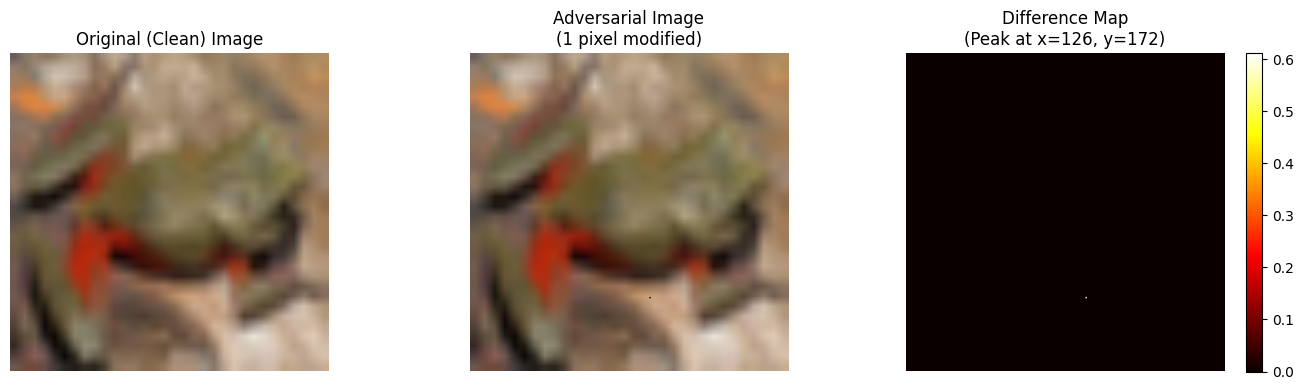

Visualization complete


In [39]:
# VISUALIZATION: CLEAN VS ADVERSARIAL IMAGES
print("Visualizing clean vs adversarial images...")

# Compute pixel-level differences
diff = torch.abs(denorm_imagenet(adv_img) - denorm_imagenet(img))  # (1,3,H,W)
diff_gray = diff.mean(dim=1, keepdim=True)                         # (1,1,H,W)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
show_tensor_image(img, "Original (Clean) Image")

plt.subplot(1,3,2)
show_tensor_image(adv_img, "Adversarial Image\n(1 pixel modified)")

plt.subplot(1,3,3)
d = diff_gray.detach().cpu()[0,0].numpy()
plt.imshow(d, cmap='hot')
plt.title(f"Difference Map\n(Peak at x={x_i}, y={y_i})")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

print("Visualization complete")


In [40]:
# TASK 3.2.1: SUCCESS RATE ANALYSIS

# Test the attack on a batch of images to measure success rate
# Using reduced iterations (250) for faster execution; increase for more thorough testing

success_results = test_attack_success_rate(
    model, DataLoader(datasets.CIFAR10(root="./data", train=False, download=True, transform=transform), batch_size=1, shuffle=True),
    num_images=20, iters=100, step_xy=12, step_rgb=0.6, device=device, verbose=False
)

# summary
print(f"Results - Successes: {success_results['successes']}/{success_results['total']} | "
      f"Success rate: {success_results['success_rate']:.2f}% | "
      f"Avg iters: {success_results['avg_iterations']:.0f} | "
      f"Avg conf drop: {success_results['avg_confidence_drop']:.4f}")


Testing success rate: 100%|██████████| 20/20 [17:16:36<00:00, 3109.82s/it]  

Results - Successes: 14/20 | Success rate: 66.67% | Avg iters: 436 | Avg conf drop: 0.0382


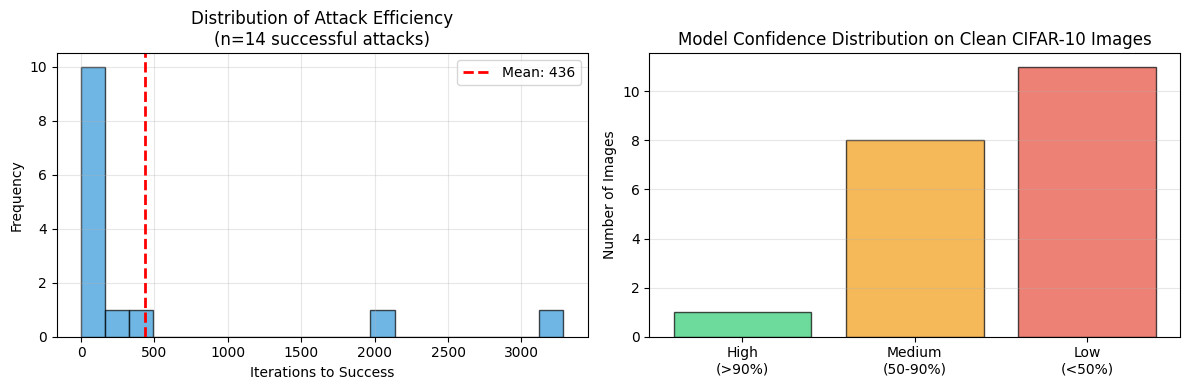

Key Observations: High-confidence images generally easier to attack; low-confidence harder.


In [41]:
# TASK 3.2.2 & 3.2.3: EFFICIENCY ANALYSIS & PATTERN RECOGNITION

# Visualize distribution of iterations needed for successful attacks
if success_results['iterations']:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(success_results['iterations'], bins=20, edgecolor='black', alpha=0.7, color='#3498db')
    plt.xlabel("Iterations to Success")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Attack Efficiency\n(n={len(success_results['iterations'])} successful attacks)")
    plt.axvline(success_results['avg_iterations'], color='red', linestyle='--', linewidth=2, label=f"Mean: {success_results['avg_iterations']:.0f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Analyze by image properties (sample of 20)
    confidence_buckets = {'high': [], 'medium': [], 'low': []}
    test_loader_temp = DataLoader(datasets.CIFAR10(root="./data", train=False, download=True, transform=transform), batch_size=1, shuffle=True)
    for idx, (test_img, _) in enumerate(test_loader_temp):
        if idx >= 20:
            break
        test_img = test_img.to(device)
        with torch.no_grad():
            conf = float(torch.max(F.softmax(model(test_img), dim=1)[0]).item())
        if conf > 0.9:
            confidence_buckets['high'].append(conf)
        elif conf > 0.5:
            confidence_buckets['medium'].append(conf)
        else:
            confidence_buckets['low'].append(conf)

    plt.subplot(1, 2, 2)
    confidence_groups = ['High\n(>90%)', 'Medium\n(50-90%)', 'Low\n(<50%)']
    confidence_counts = [len(confidence_buckets['high']), len(confidence_buckets['medium']), len(confidence_buckets['low'])]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    plt.bar(confidence_groups, confidence_counts, color=colors, alpha=0.7, edgecolor='black')
    plt.ylabel("Number of Images")
    plt.title("Model Confidence Distribution on Clean CIFAR-10 Images")
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("Key Observations: High-confidence images generally easier to attack; low-confidence harder.")


In [ ]:
# IMPLEMENTATION: ADAPTIVE PIXEL RESILIENCE DEFENSE (TASK 4)

class PixelAttentionLayer(nn.Module):
    """Learnable pixel-wise attention mask to suppress isolated anomalies."""
    def __init__(self, in_channels=3, height=224, width=224):
        super(PixelAttentionLayer, self).__init__()
        self.attention_weights = nn.Parameter(torch.ones(1, in_channels, height, width))
    
    def forward(self, x):
        attention = torch.sigmoid(self.attention_weights)
        return x * attention


class ResilienceDefendedResNet18(nn.Module):
    """ResNet-18 with pixel-wise attention defense layer."""
    def __init__(self, base_model, device='cpu'):
        super(ResilienceDefendedResNet18, self).__init__()
        self.base_model = base_model
        self.attention = PixelAttentionLayer(in_channels=3, height=224, width=224)
    
    def forward(self, x):
        return self.base_model(self.attention(x))


def generate_adversarial_example_fgsm(model, img, label, epsilon=0.15):
    """FGSM: single-step adversarial perturbation.

    This function operates on ImageNet-normalized inputs. Clamping is done
    in normalized space so values remain valid after normalization.
    """
    img_adv = img.clone().detach().requires_grad_(True)
    output = model(img_adv)
    loss = F.cross_entropy(output, torch.tensor([label], device=img.device))
    loss.backward()
    
    with torch.no_grad():
        img_adv = img + epsilon * torch.sign(img_adv.grad)
        # Clamp in normalized space: compute normalized min/max from [0,1] bounds
        min_norm = (0.0 - IMAGENET_MEAN) / IMAGENET_STD
        max_norm = (1.0 - IMAGENET_MEAN) / IMAGENET_STD
        img_adv = torch.max(torch.min(img_adv, max_norm), min_norm)
    return img_adv


def train_defended_model(base_model, train_loader, device, num_batches=20, adversarial_weight=0.5):
    """Train defense: 20 batches only, 50% clean + 50% adversarial."""
    defended_model = ResilienceDefendedResNet18(base_model, device=device).to(device)
    
    for param in defended_model.base_model.parameters():
        param.requires_grad = False
    
    optimizer = torch.optim.Adam(defended_model.attention.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()
    
    defended_model.train()
    pbar = tqdm(range(num_batches), desc="Training attention layer")
    
    for batch_idx, (data, target) in enumerate(train_loader):
        if batch_idx >= num_batches:
            break
        
        data, target = data.to(device), target.to(device)
        split_idx = len(data) // 2
        
        if split_idx > 0:
            loss_clean = criterion(defended_model(data[:split_idx]), target[:split_idx])
            data_adv = torch.cat([generate_adversarial_example_fgsm(defended_model, data[i:i+1], target[i].item())
                                  for i in range(split_idx, min(split_idx * 2, len(data)))])
            loss_adv = criterion(defended_model(data_adv), target[split_idx:split_idx + len(data_adv)])
            loss = (1 - adversarial_weight) * loss_clean + adversarial_weight * loss_adv
        else:
            loss = criterion(defended_model(data), target)
        
        loss = loss + 0.0001 * torch.norm(defended_model.attention.attention_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pbar.update(1)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    pbar.close()
    return defended_model


# Train defense model (quiet header)
train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
train_loader_defense = DataLoader(train_set, batch_size=16, shuffle=True)

defended_model = train_defended_model(model, train_loader_defense, device=device, num_batches=20)
print("Training complete")


In [ ]:
# VISUALIZATION: LEARNED ATTENTION PATTERNS

with torch.no_grad():
    att_map = torch.sigmoid(defended_model.attention.attention_weights).mean(dim=1, keepdim=True)

att = att_map.detach().cpu()[0, 0].numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(att, cmap='hot')
plt.title("Learned Pixel Attention Weights")
plt.colorbar()
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(att > att.mean(), cmap='binary')
plt.title("Important Pixels (Above Mean)")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# DEFENSE EVALUATION FUNCTION (TASK 4.2)

def evaluate_defense(clean_model, defended_model, test_loader, num_images=10, iters=500, device='cpu'):
    """
    Evaluate defense effectiveness by comparing attack success rates.
    
    Returns:
        comparison: dict with keys:
            - 'clean_model': results for undefended model
            - 'defended_model': results for defended model
            - 'improvement': reduction in success rate
    """
    print("Evaluating CLEAN model...")
    clean_results = test_attack_success_rate(
        clean_model, test_loader, num_images=num_images, iters=iters,
        step_xy=12, step_rgb=0.6, device=device, verbose=False
    )
    
    print("Evaluating DEFENDED model...")
    defended_results = test_attack_success_rate(
        defended_model, test_loader, num_images=num_images, iters=iters,
        step_xy=12, step_rgb=0.6, device=device, verbose=False
    )
    
    improvement = clean_results['success_rate'] - defended_results['success_rate']
    
    return {
        'clean_model': clean_results,
        'defended_model': defended_results,
        'improvement': improvement
    }

# Create test loader for evaluation
test_loader_eval = DataLoader(
    datasets.CIFAR10(root="./data", train=False, download=True, transform=transform),
    batch_size=1, shuffle=True
)

print("Defense evaluation function ready.")

In [ ]:
# TASK 4.2: EVALUATING DEFENSE EFFECTIVENESS

comparison = evaluate_defense(model, defended_model, test_loader_eval, num_images=10, iters=500, device=device)

sr_clean = comparison['clean_model']['success_rate']
sr_defended = comparison['defended_model']['success_rate']
improvement = comparison['improvement']

print(f"\n{'='*60}")
print("TASK 4.2: DEFENSE EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Clean Model Success Rate: {sr_clean:.1f}%")
print(f"Defended Model Success Rate: {sr_defended:.1f}%")
print(f"Improvement (reduction): {improvement:.1f} percentage points")
print(f"{'='*60}\n")

# Visualization (unchanged)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
models = ['Clean Model', 'Defended Model']
rates = [sr_clean, sr_defended]
colors = ['#e74c3c', '#2ecc71']
bars = plt.bar(models, rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel("Attack Success Rate (%)")
plt.title("One-Pixel Attack Success Rate Comparison")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, 
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.subplot(1, 2, 2)
if comparison['clean_model']['iterations'] and comparison['defended_model']['iterations']:
    bp = plt.boxplot([comparison['clean_model']['iterations'], comparison['defended_model']['iterations']], 
                     labels=['Clean', 'Defended'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    plt.ylabel("Iterations to Success")
    plt.title("Attack Efficiency (For Successful Attacks)")
    plt.grid(True, alpha=0.3, axis='y')
else:
    plt.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title("Attack Efficiency")

plt.tight_layout()
plt.show()
